# Replication of Water Isotope Analysis

This notebook replicates the analysis performed by the analyst in the Excel file `DATA/datos 2H y 18O procesados.xlsx` using the `isotools` library.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from isotools import Batch, WATER_H, WATER_O, MultiPointLinear

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')


sns.set_theme(style="whitegrid")

## 1. Process Hydrogen (2H)

In [2]:
filepath = "DATA/datos 2H y 18O procesados.xlsx"

# Initialize Batch for 2H (sheet '2H.wke')
batch_h = Batch(filepath, config=WATER_H, sheet_name="2H.wke")

# Set Anchor Standards
batch_h.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H", "Antartida_H"])

### 1.1 Inspect and Clean Data
We can inspect the loaded sequence and exclude any failed injections.

In [3]:
# View raw data for preliminary analysis
display(batch_h.data_view)



,Date,Time,row,sample_name,sample_id_2,Amount,Comment,peak_nr,amp_2,area_2,Ampl 3,Area 3,R 3H2/2H2,d2h,excluded,working_value
2,04/20/26,18:12:58,1,Mar,NaN,NaN,NaN,3,2766,23.810,1065,0.009,0.000390,253.256,False,253.256
5,04/20/26,18:21:59,2,Mar,NaN,NaN,NaN,3,2766,23.738,1064,0.009,0.000391,254.877,False,254.877
8,04/20/26,18:31:01,3,Mar,NaN,NaN,NaN,3,2775,23.765,1069,0.009,0.000390,252.970,False,252.970
11,04/20/26,18:40:03,4,Buenos Aires,NaN,NaN,NaN,3,2785,23.623,1036,0.008,0.000376,207.583,False,207.583
14,04/20/26,18:49:04,5,Buenos Aires,NaN,NaN,NaN,3,2838,24.614,1057,0.009,0.000377,209.739,False,209.739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,04/21/26,12:31:47,122,Mendoza,NaN,NaN,NaN,3,2725,24.742,981,0.008,0.000363,165.310,False,165.310
368,04/21/26,12:40:48,123,Mendoza,NaN,NaN,NaN,3,2739,24.966,986,0.008,0.000363,165.476,False,165.476
371,04/21/26,12:49:50,124,Antartida,NaN,NaN,NaN,3,2732,24.816,964,0.008,0.000355,139.352,False,139.352
374,04/21/26,12:58:52,125,Antartida,NaN,NaN,NaN,3,2787,25.276,982,0.008,0.000355,138.314,False,138.314


### 1.2 Drift Analysis (2H)
We check for analytical drift using the 'Buenos Aires_H' standard which is measured throughout the run.

,Slope,CI_95,p_value,R_squared,n
Standard,,,,,
Buenos Aires_H,0.00402,0.018166,0.649365,0.01054,22


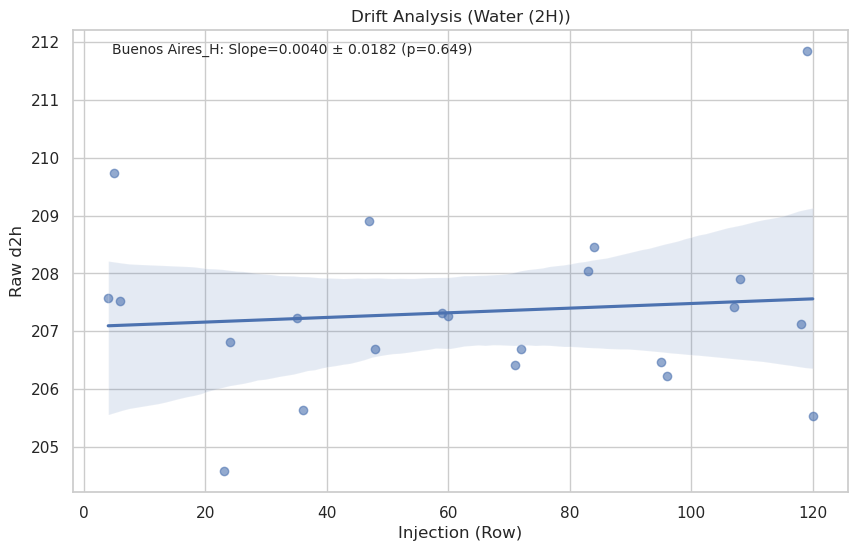

In [4]:
batch_h.set_drift_monitors(["Buenos Aires_H"])

# Check drift statistics
drift_stats_h = batch_h.check_drift()
display(drift_stats_h)

# Plot drift
batch_h.plot_drift();

### 1.2 Processing

2H Instrument Slope (m): 1.2299
2H Instrument Intercept (b): 254.7440


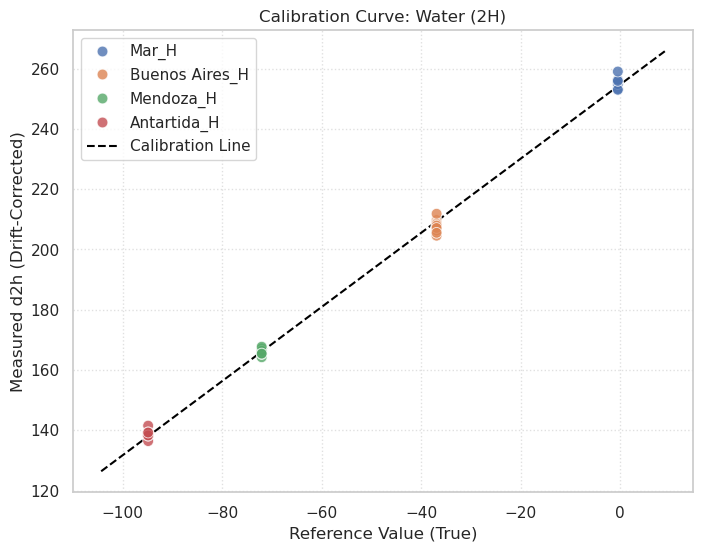

In [5]:
# Process using Multi-Point Linear (OLS)
# Note: Fitting follows convention Raw = m * True + b
batch_h.process(strategy=MultiPointLinear())

print(f"2H Instrument Slope (m): {batch_h._strategy.slope:.4f}")
print(f"2H Instrument Intercept (b): {batch_h._strategy.intercept:.4f}")

# Visualize Calibration Curve
batch_h.plot_calibration();

In [6]:
batch_h.report.head(15)

,corrected_d2h,combined_uncertainty,count
group_name,,,
A003,-7.47,1.77,2
A016,-3.64,1.89,2
A017,-94.29,1.18,2
A018,-75.35,1.28,2
A019,-35.08,0.85,2
A020,-15.46,1.08,2
A021,-53.38,0.91,2
A022,-76.10,1.90,2
A023,-110.35,1.76,2


### 1.3 Uncertainty Comparison (2H)
Now we process the 2H data using the method precision (1.4‰) and compare the resulting uncertainties with the empirical ones. This is particularly useful when replicate counts are low.

In [7]:
# 1. Initialize a new batch for precision comparison
batch_h_prec = Batch(filepath, config=WATER_H, sheet_name="2H.wke")

# 2. Set Anchors and process with method precision
batch_h_prec.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H", "Antartida_H"])
batch_h_prec.process(strategy=MultiPointLinear(), use_method_precision=True)

# 3. Compare uncertainties
comp_unc_h = pd.DataFrame({
    "Empirical Unc": batch_h.report["combined_uncertainty"],
    "Method Precision Unc": batch_h_prec.report["combined_uncertainty"]
})

print("Comparison of Combined Uncertainties (2H):")
display(comp_unc_h.head(15))


Comparison of Combined Uncertainties (2H):


,Empirical Unc,Method Precision Unc
group_name,,
A003,1.77,1.38
A016,1.89,1.43
A017,1.18,1.36
A018,1.28,1.17
A019,0.85,1.12
A020,1.08,1.28
A021,0.91,1.07
A022,1.90,1.17
A023,1.76,1.58


## 2. Process Oxygen (18O)

In [8]:
# Initialize Batch for 18O (sheet '18O.wke')
batch_o = Batch(filepath, config=WATER_O, sheet_name="18O.wke")

# Set Anchor Standards
batch_o.set_anchors(["Mar_O", "Buenos Aires_O", "Mendoza_O", "Antartida_O"])

/home/damianp/Proyectos/isotools/isotools/core.py:62: UserWarning: Detected 2 suspicious data points on initial load. Check the .alerts property for details.
  warnings.warn(


In [9]:
display(batch_o.alerts)

,row,sample_name,reason
0,113,A016,High Variance: SD (46.92) > 3x method precisio...
1,114,A016,High Variance: SD (46.92) > 3x method precisio...


In [10]:
# exclude outlier
batch_o.exclude_rows([113])

### 2.1 Drift Analysis (18O)

,Slope,CI_95,p_value,R_squared,n
Standard,,,,,
Buenos Aires_O,0.001726,0.001194,0.00684,0.31249,22


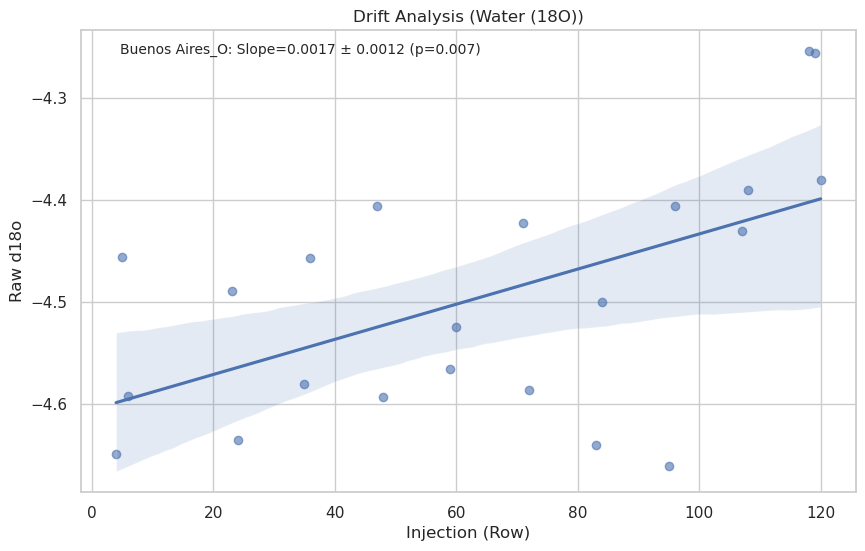

In [11]:
batch_o.set_drift_monitors(["Buenos Aires_O"])

# Check drift statistics
drift_stats_o = batch_o.check_drift()
display(drift_stats_o)

# Plot drift
batch_o.plot_drift();

### 2.2 Processing (No Drift Correction)

18O Instrument Slope (m): 1.0532
18O Instrument Intercept (b): 1.8667


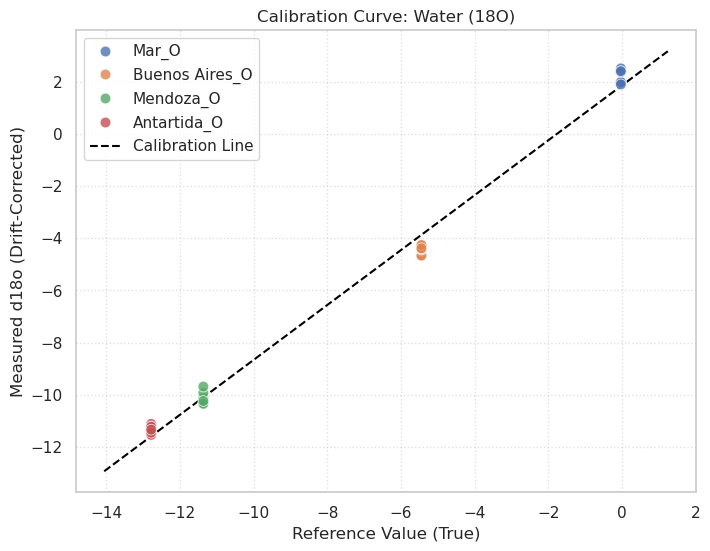

In [12]:
# Process using Multi-Point Linear (OLS)
batch_o.process(strategy=MultiPointLinear())

print(f"18O Instrument Slope (m): {batch_o._strategy.slope:.4f}")
print(f"18O Instrument Intercept (b): {batch_o._strategy.intercept:.4f}")

# Visualize Calibration Curve
batch_o.plot_calibration();

In [13]:
batch_h.report.head(15)

,corrected_d2h,combined_uncertainty,count
group_name,,,
A003,-7.47,1.77,2
A016,-3.64,1.89,2
A017,-94.29,1.18,2
A018,-75.35,1.28,2
A019,-35.08,0.85,2
A020,-15.46,1.08,2
A021,-53.38,0.91,2
A022,-76.10,1.90,2
A023,-110.35,1.76,2


### 1.3 Uncertainty Comparison (2H)
Now we process the 2H data using the method precision (1.4‰) and compare the resulting uncertainties with the empirical ones. This is particularly useful when replicate counts are low.

In [14]:
# 1. Initialize a new batch for precision comparison
batch_h_prec = Batch(filepath, config=WATER_H, sheet_name="2H.wke")

# 2. Set Anchors and process with method precision
batch_h_prec.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H", "Antartida_H"])
batch_h_prec.process(strategy=MultiPointLinear(), use_method_precision=True)

# 3. Compare uncertainties
comp_unc_h = pd.DataFrame({
    "Empirical Unc": batch_h.report["combined_uncertainty"],
    "Method Precision Unc": batch_h_prec.report["combined_uncertainty"]
})

print("Comparison of Combined Uncertainties (2H):")
display(comp_unc_h.head(15))


Comparison of Combined Uncertainties (2H):


,Empirical Unc,Method Precision Unc
group_name,,
A003,1.77,1.38
A016,1.89,1.43
A017,1.18,1.36
A018,1.28,1.17
A019,0.85,1.12
A020,1.08,1.28
A021,0.91,1.07
A022,1.90,1.17
A023,1.76,1.58


### 2.3 Drift Correction Comparison (18O)
Now we apply a linear drift correction to the 18O data using 'Buenos Aires_O' as the monitor and compare the results with the uncorrected run.

Corrected 18O Instrument Slope (m): 1.0543


/home/damianp/Proyectos/isotools/isotools/core.py:62: UserWarning: Detected 2 suspicious data points on initial load. Check the .alerts property for details.
  warnings.warn(


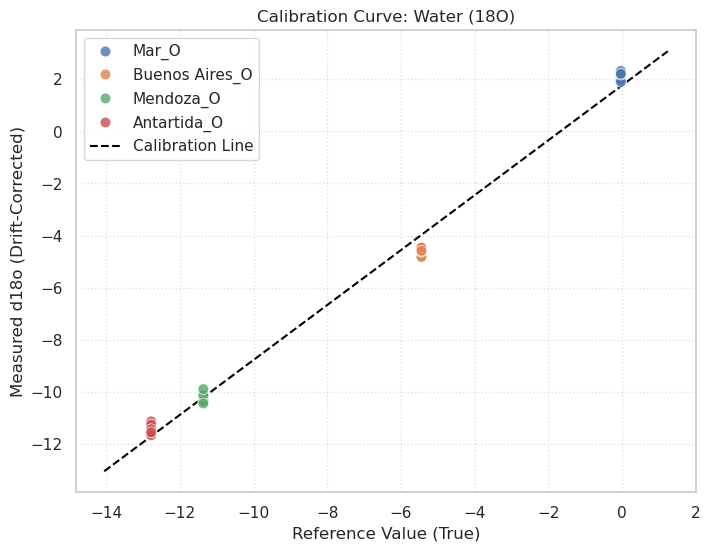

In [15]:
# 1. Initialize a new batch for comparison
batch_o_corr = Batch(filepath, config=WATER_O, sheet_name="18O.wke")
batch_o_corr.exclude_rows([113])  # Exclude outlier

# 2. Identify and Apply Drift Correction
batch_o_corr.set_drift_monitors(["Buenos Aires_O"])
batch_o_corr.apply_drift_correction("Buenos Aires_O")

# 3. Set same anchors and process
batch_o_corr.set_anchors(["Mar_O", "Buenos Aires_O", "Mendoza_O", "Antartida_O"])
batch_o_corr.process(strategy=MultiPointLinear())

print(f"Corrected 18O Instrument Slope (m): {batch_o_corr._strategy.slope:.4f}")

# Visualize Corrected Calibration Curve
batch_o_corr.plot_calibration();

In [16]:
batch_o_corr.alerts

""


In [17]:
# Compare final results
comp = pd.DataFrame({
    "Uncorrected": batch_o.report["corrected_d18o"],
    "Drift-Corrected": batch_o_corr.report["corrected_d18o"]
})
comp["Difference"] = comp["Drift-Corrected"] - comp["Uncorrected"]

print("Comparison of Sample Values:")
display(comp.head(15))

Comparison of Sample Values:


,Uncorrected,Drift-Corrected,Difference
group_name,,,
A003,-3.66,-3.75,-0.09
A016,-2.28,-2.36,-0.08
A017,-13.94,-13.85,0.09
A018,-12.01,-11.92,0.09
A019,-6.31,-6.24,0.07
A020,-3.46,-3.39,0.07
A021,-7.60,-7.53,0.07
A022,-11.01,-10.94,0.07
A023,-15.25,-15.19,0.06


## 3. QA/QC and Independent Verification

A robust IRMS workflow uses some standards as 'Anchors' to build the calibration model, and others as 'Controls' (or QCs) to verify its accuracy. 

Here we re-process the data using a subset of anchors and use 'Antartida' as an independent control to check the trueness of our calibration.

In [18]:
# 1. Re-configure 2H Batch: Use only 3 anchors, 1 control
batch_h.set_anchors(["Mar_H", "Buenos Aires_H", "Mendoza_H"])
batch_h.set_controls(["Antartida_H"])
batch_h.process(strategy=MultiPointLinear(), use_method_precision=True)


print("QA/QC Report for 2H (Antartida as independent control):")
display(batch_h.qaqc)


QA/QC Report for 2H (Antartida as independent control):


,True_Value,corrected_d2h,Bias,Within_Unc
Antartida_H,-94.89,-93.158077,1.731923,True


## 4. Dual Isotope Analysis & Meteoric Water Line

In water isotope studies, Hydrogen and Oxygen data are often combined to calculate **Deuterium Excess (d-excess)** and plotted against the **Global Meteoric Water Line (GMWL)**.

Combined Isotope Results (First 10 rows):


,d2H,u2H,count,d18O,u18O,d_excess
group_name,,,,,,
A003,-7.69,1.40,2,-3.66,0.17,21.59
A016,-3.91,1.46,2,-2.28,NaN,14.33
A017,-93.21,1.94,2,-13.94,0.19,18.31
A018,-74.56,1.55,2,-12.01,0.16,21.52
A019,-34.88,1.13,2,-6.31,0.32,15.60
A020,-15.56,1.28,2,-3.46,0.15,12.12
A021,-52.91,1.22,2,-7.60,0.13,7.89
A022,-75.30,1.56,2,-11.01,0.21,12.78
A023,-109.04,2.32,2,-15.25,0.25,12.96


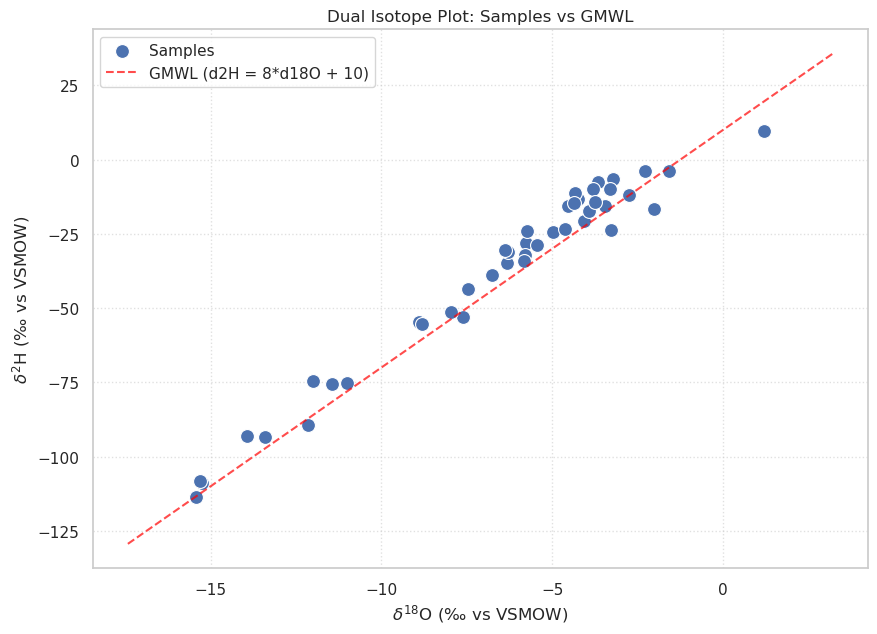

In [19]:
# 1. Combine results from both batches
results_h = batch_h.report.rename(columns={"corrected_d2h": "d2H", "combined_uncertainty": "u2H"})
results_o = batch_o.report.rename(columns={"corrected_d18o": "d18O", "combined_uncertainty": "u18O"})

dual_iso = results_h.join(results_o[["d18O", "u18O"]], how="inner")

# 2. Calculate Deuterium Excess: d = d2H - 8 * d18O
dual_iso["d_excess"] = dual_iso["d2H"] - 8 * dual_iso["d18O"]

print("Combined Isotope Results (First 10 rows):")
display(dual_iso.head(10))

# 3. Plot d18O vs d2H with GMWL
plt.figure(figsize=(10, 7))

# Filter out standards for a cleaner plot of samples
samples_only = dual_iso[~dual_iso.index.str.contains("H|_O")]

sns.scatterplot(data=samples_only, x="d18O", y="d2H", s=100, label="Samples")

# Add GMWL: d2H = 8 * d18O + 10
x_gmwl = np.array([dual_iso["d18O"].min() - 2, dual_iso["d18O"].max() + 2])
y_gmwl = 8 * x_gmwl + 10
plt.plot(x_gmwl, y_gmwl, color='red', linestyle='--', alpha=0.7, label='GMWL (d2H = 8*d18O + 10)')

plt.title("Dual Isotope Plot: Samples vs GMWL")
plt.xlabel("$\\delta^{18}$O (‰ vs VSMOW)")
plt.ylabel("$\\delta^{2}$H (‰ vs VSMOW)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 5. Data Export

Finally, we can export the processed data, including the QA/QC results and all metadata, to formatted Excel files.

In [20]:
# Export final reports
batch_h.save_report("Water_2H_Report.xlsx")
batch_o.save_report("Water_18O_Report.xlsx")
print("Reports successfully exported to 'Water_2H_Report.xlsx' and 'Water_18O_Report.xlsx'.")

batch_h.save_html_report("Water_2H_Report.html")
batch_o.save_html_report("Water_18O_Report.html")
print("HTML reports successfully exported to 'Water_2H_Report.html' and 'Water_18O_Report.html'.")

Reports successfully exported to 'Water_2H_Report.xlsx' and 'Water_18O_Report.xlsx'.
HTML reports successfully exported to 'Water_2H_Report.html' and 'Water_18O_Report.html'.


## 6. Summary

This notebook demonstrates the full `isotools` workflow for water isotope analysis:
- Automated data loading and peak filtering.
- Drift analysis and linear correction.
- Multi-point linear calibration using OLS.
- Rigorous uncertainty propagation (Kragten).
- Independent QA/QC verification.
- Dual-isotope interpretation (d-excess and GMWL).
